In [ ]:
# pandas is used to load and manipulate datasets (needed for datasets)
import pandas as pd

# numpy is used for numerical operations and arrays
import numpy as np

# matplotlib is the main plotting library used for graphs
import matplotlib.pyplot as plt

# seaborn creates nicer looking graphs (hella aesthetic)
import seaborn as sns

# train_test_split is used to split our dataset into training and testing data (needed for training and then testing how well it trained)
from sklearn.model_selection import train_test_split

# learning_curve helps visualize how the model improves with more training and data (similar to me learning how to make this)
from sklearn.model_selection import learning_curve

# CountVectorizer converts text into numbers by counting the occurrences of words
from sklearn.feature_extraction.text import CountVectorizer

# MultinomialNB is a machine learning algorithm for text classification
from sklearn.naive_bayes import MultinomialNB

# accuracy_score measures the percentage of correct predictions
from sklearn.metrics import accuracy_score

# confusion_matrix helps evaluate classification results (just as confused as i am but oh well)
from sklearn.metrics import confusion_matrix

# WordCloud creates word cloud diagram (hella tuff)
from wordcloud import WordCloud

# makes graph background white and makes it wayyyyyy tuffer
sns.set(style="whitegrid")

In [ ]:
# URL that contains the msgs that are labeled as 'ham' or 'spam'
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# read the dataset into a pandas DataFrame, and then orgnaizing it into 2 columns
data = pd.read_csv(url, sep="\t", names=["label","message"])

# print the number of rows and columns in the dataset (its a lot, but not a lot compared to large scale models)
print("\nDataset size:", data.shape)


Dataset size: (5572, 2)


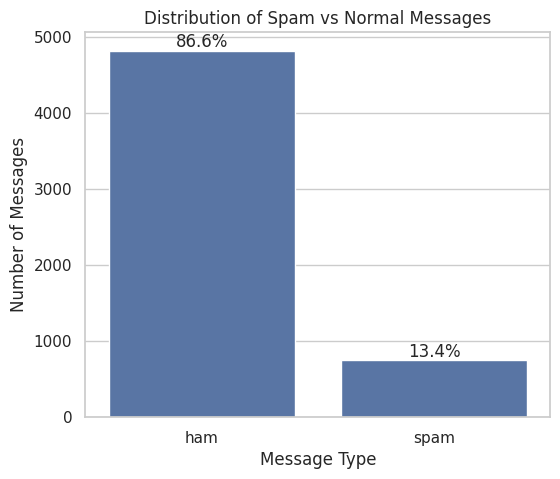

In [ ]:
# count how many times each ham appears and spam appears
counts = data["label"].value_counts()

# creating the grid and plotting a bar graph
plt.figure(figsize=(6,5))
sns.barplot(x=counts.index, y=counts.values)
total = counts.sum()

# adds the percentage over the bars in the graph
for i, v in enumerate(counts.values):
    percent = (v/total)*100
    plt.text(i, v + 50, f"{percent:.1f}%", ha='center')

# title, x-axis, y-axis (someone will get disappointed if i dont have this labeled)
plt.title("Distribution of Spam vs Normal Messages")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

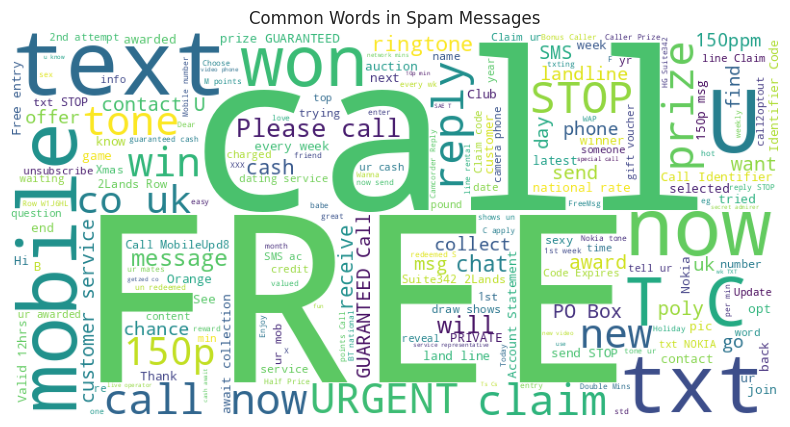

In [ ]:
# makes all the spam msgs into one giant string
spam_text = " ".join(data[data["label"]=="spam"]["message"])

# create a WordCloud image and generating it based on the spam messages
wordcloud = WordCloud(width=800,height=400,background_color="white").generate(spam_text)

# creating the figure and displaying the WordCloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")

# title
plt.title("Common Words in Spam Messages")
plt.show()

In [ ]:
# makes the values from text to numbers
# ham is 0 and spam is 1 (BINARYYYYYYYY)
data["label_num"] = data.label.map({"ham":0, "spam":1})

In [ ]:
# X is the msgs
X = data["message"]

# y is the label (NEW LABELS: 0=ham, 1=spam)
y = data["label_num"]

# Split dataset into into 80% training, 20% testing
# random_state ensures it can be repeated (needed for more testing and runs)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# converts text into numbers and stop_words removes common words like 'the' and 'and' (makes it easier for the model and simplfies model training)
vectorizer = CountVectorizer(stop_words="english")

# fit the vectorizer on the training data and transform training messages
X_train_vec = vectorizer.fit_transform(X_train)

# transform test messages
X_test_vec = vectorizer.transform(X_test)

In [ ]:
# creating and using a Multinomial Naive Bayes model
# rlly rlly rlly good for text classification
model = MultinomialNB()

# training the model on vectorized training data
model.fit(X_train_vec, y_train)

MultinomialNB()

In [ ]:
# use trained model to predict labels for the TESTING set
predictions = model.predict(X_test_vec)

# calculate the accuracy
accuracy = accuracy_score(y_test, predictions)

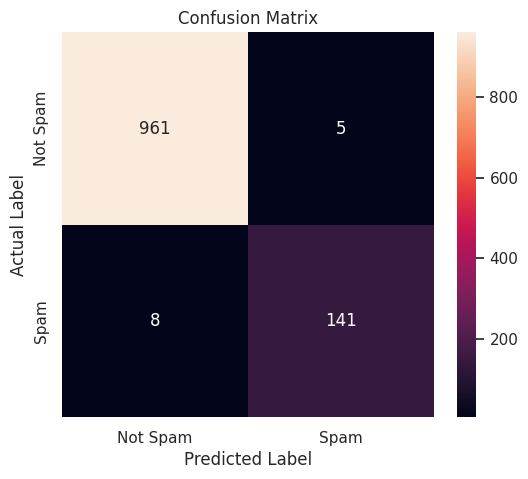

In [ ]:
# computer the confusion matrix to see correct vs incorrect predictions
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

# creating a confusion matrix (cm) as a heatmap
sns.heatmap(cm, annot=True,fmt="d",xticklabels=["Not Spam","Spam"],yticklabels=["Not Spam","Spam"])

# title, x-axis, y-axis
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

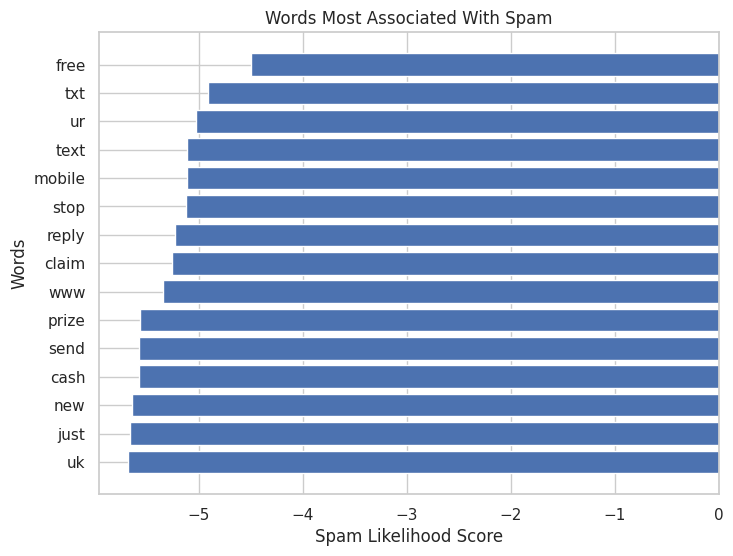

In [ ]:
# create an array of all the words in the stored vocab
words = np.array(vectorizer.get_feature_names_out())

# get the probabilty for each word appearing
spam_probs = model.feature_log_prob_[1]

# find the indexes of the t15
top_indices = np.argsort(spam_probs)[-15:]

# extract tham and there spam scores
top_words = words[top_indices]
top_scores = spam_probs[top_indices]

# plot it
plt.figure(figsize=(8,6))
plt.barh(top_words, top_scores)

# title, x-axis, y-axis
plt.title("Words Most Associated With Spam")
plt.xlabel("Spam Likelihood Score")
plt.ylabel("Words")

plt.show()

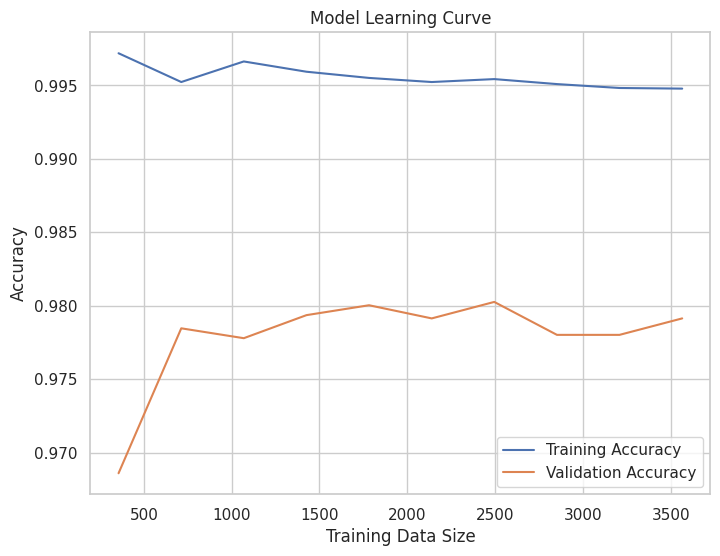

Model Accuracy: 0.9883408071748879


In [ ]:
train_sizes, train_scores, test_scores = learning_curve(model,X_train_vec,y_train,cv=5,scoring="accuracy",train_sizes=np.linspace(0.1, 1.0, 10))

# average training and validation scores
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# plot it
plt.figure(figsize=(8,6))

# labels
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, test_mean, label="Validation Accuracy")
plt.title("Model Learning Curve")
plt.xlabel("Training Data Size")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# print model accuracy (should be around 98%)
print("Model Accuracy:", accuracy)

In [ ]:
while True:
    user_input = input("\nEnter message to classify (or 'quit'): ")

    if user_input.lower() == "quit":
        break

    # convert the input msg into a vector
    message_vec = vectorizer.transform([user_input])

    # pass thru model
    prediction = model.predict(message_vec)

    # print the result result
    if prediction[0] == 1:
        print("Prediction: SPAM")
    else:
        print("Prediction: NOT SPAM (ITS SAFE)")

Prediction: SPAM
Prediction: NOT SPAM (ITS SAFE)
Prediction: NOT SPAM (ITS SAFE)
Prediction: SPAM
